# Advanced affine diagnostics and non-rigid correction: WS2 0070/0071

This pair demonstrates a failure mode specific to periodic atomic images. A
whole-image affine score can prefer a neighboring unit-cell translation even
when defects no longer correspond. The upper-left region contains trustworthy
defect correspondence, so it establishes the affine branch for the complete
field. Regional diagnostics then show where non-rigid correction is still
needed.

This is an **advanced validation workflow**. Start with the normal automatic
`correct_affine()` tutorial for routine data. Use this notebook only when the
RGB overlay shows a unit-cell hop or different regions prefer different rigid
translations.

The regional affine anchor selects the correct lattice branch. This difficult
pair then uses six knots per scanline so non-rigid correction can represent
the fast-scan variation that remains across the complete field.


## Device and paths


In [1]:
from pathlib import Path

import quantem.widget as qw
from quantem.imaging import DriftCorrection

DATA = Path("../data/robustness/wmill_ws2")
RESULT = DATA / "drift_0070_0071_diagnostics.zip"

# Interactive is the recommended default. False uses static/report rendering.
INTERACTIVE = True
VIEW_MODE = "interactive" if INTERACTIVE else "static"

qw.profile()


quantem.widget  0.0.1rc36
  install       published package
quantem.gpu     0.0.1rc6
  install       editable checkout
quantem         0.1.9
torch           2.13.0  device=cuda (NVIDIA RTX PRO 6000 Blackwell Max-Q Workstation Edition)
GPUs            1 visible (CUDA_VISIBLE_DEVICES=1)
  GPU0           23.5 used / 102 GB  (78 free)
  torch pool    0.0 live / 0.0 reserved GB
python          3.14.6


## Load the orthogonal EMD pair

`from_emd` reads both scan directions and calibration from Velox metadata.


In [2]:
drift = DriftCorrection.from_emd(
    DATA / "0070 - VWS2_9h_g_300kv STEM HAADF 5.20 Mx Diffraction.emd",
    DATA / "0071 - VWS2_9h_g_300kv STEM HAADF 5.20 Mx Diffraction.emd",
    verbose=False,
)


## Fit affine from the trusted upper-left region

`region="top_left"` selects the physical upper-left quadrant without requiring
Python slice syntax. `correct_affine()` fits one affine drift vector and one
translation there, then applies that same affine model to the complete scans.
Knot count remains a non-rigid decision made later in the workflow. Both
orthogonal scans remain free.


In [3]:
drift.correct_affine(
    region="top_left",
    region_smoothing_sigma=4.0,
    max_image_shift=64,
    show_combined=False,
    show_scans=False,
    show_knots=False,
    verbose=True,
)


correct_affine: automatic pyramid 8x, 5 native candidates, 0.34 s
Drift: (-0.01367, +0.03555) px/line; translation bound 64 px


## Inspect the affine result


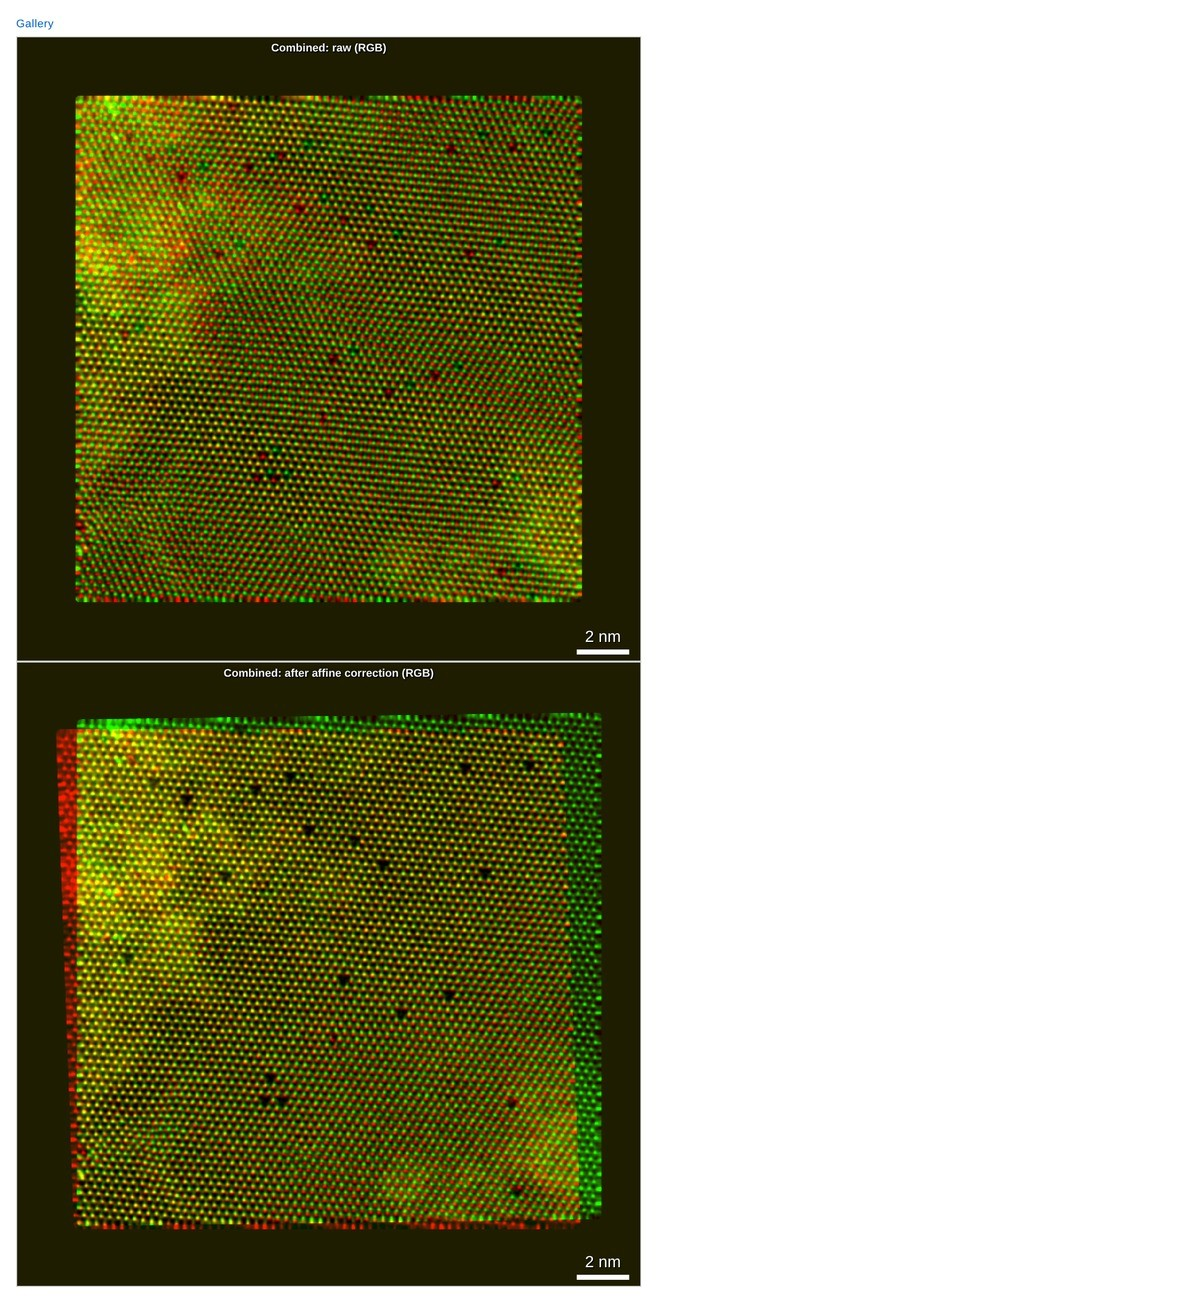

In [4]:
drift.plot_combined(
    stage=("initial", "affine"),
    interactive=INTERACTIVE,
    width=620,
)


## Regional affine diagnostic

The search uses sigma 4 for stability, but acceptance is checked with sigma
0.5 so atomic detail remains visible. The title records the trusted region and
the single affine drift vector applied to the complete image. Each row is one
physical quadrant. The four columns show scan 0, scan 1, their actual RGB
registration, and the absolute residual difference. The table's
NCC, yellow agreement, and mean absolute difference describe the result as it
stands. This diagnostic neither searches for nor applies another shift.


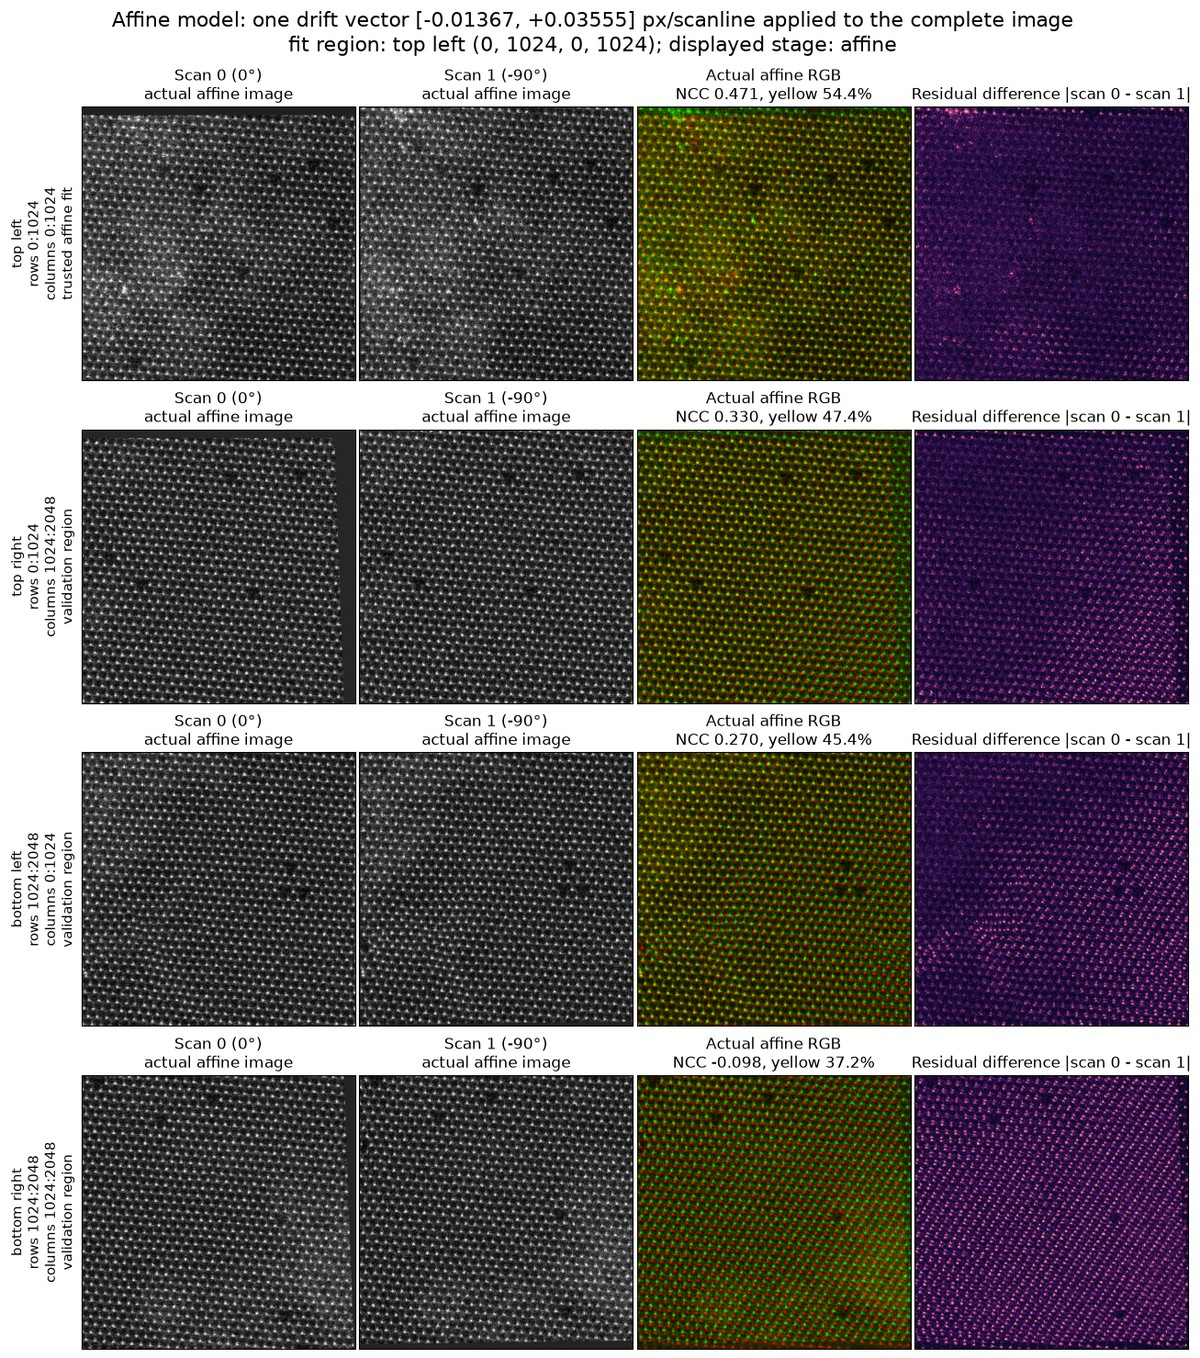

In [5]:
affine_figure, affine_regions = drift.diagnose_affine(
    stage="affine",
    smoothing_sigma=0.5,
)


In [6]:
affine_regions


,region,region_role,row_start,row_stop,column_start,column_stop,grid_row,grid_column,current_ncc,current_yellow,mean_absolute_difference
0,top left,trusted affine fit,0,1024,0,1024,0,0,0.470790,0.543680,0.041223
1,top right,validation region,0,1024,1024,2048,0,1,0.329995,0.473621,0.039716
2,bottom left,validation region,1024,2048,0,1024,1,0,0.269714,0.454064,0.044296
3,bottom right,validation region,1024,2048,1024,2048,1,1,-0.098319,0.371826,0.053800


## Apply the selected non-rigid model

Both scans remain free, so each contributes its scan-direction-dependent
drift. Six knots per scanline resolve the left/right residual difference while
keeping the deformation model compact. Smoothing 2 suppresses scanline jitter
while retaining that fast-scan freedom. Early stopping after 16 unchanged
cycles prevents continued deformation once the registration has flattened.


In [7]:
drift.correct_nonrigid(
    num_knots=6,
    optimizer="adam",
    num_refine_cycles=256,
    optimizer_steps=30,
    learning_rate=0.1,
    knot_smoothing_sigma=2.0,
    update_fraction=0.8,
    trend_order=1,
    max_image_shift=32,
    loss="mse",
    early_stop_patience=16,
    min_iterations=4,
    show_combined=False,
    show_scans=False,
    show_knots=False,
    verbose=True,
)


Solving nonrigid drift (adam):   0%|          | 0/256 [00:00<?, ?it/s]

Solving nonrigid drift (adam):   0%|          | 0/256 [00:00<?, ?it/s, error=0.005733, best=0.005733]

Solving nonrigid drift (adam):   0%|          | 1/256 [00:00<01:18,  3.24it/s, error=0.005733, best=0.005733]

Solving nonrigid drift (adam):   0%|          | 1/256 [00:00<01:18,  3.24it/s, error=0.005078, best=0.005078]

Solving nonrigid drift (adam):   1%|          | 2/256 [00:00<01:02,  4.06it/s, error=0.005078, best=0.005078]

...

Solving nonrigid drift (adam):  25%|██▍       | 63/256 [00:12<00:38,  4.98it/s, error=0.003681, best=0.003681]

Solving nonrigid drift (adam):  25%|██▌       | 64/256 [00:12<00:38,  4.98it/s, error=0.003681, best=0.003681]

Solving nonrigid drift (adam):  25%|██▌       | 64/256 [00:13<00:38,  4.98it/s, error=0.003681, best=0.003681]

Solving nonrigid drift (adam):  25%|██▌       | 64/256 [00:13<00:38,  4.98it/s, converged at cycle 65, error=0.003681, best=0.003681]

Solving nonrigid drift (adam):  25%|██▌       | 64/256 [00:13<00:39,  4.86it/s, converged at cycle 65, error=0.003681, best=0.003681]

## Compare all stages


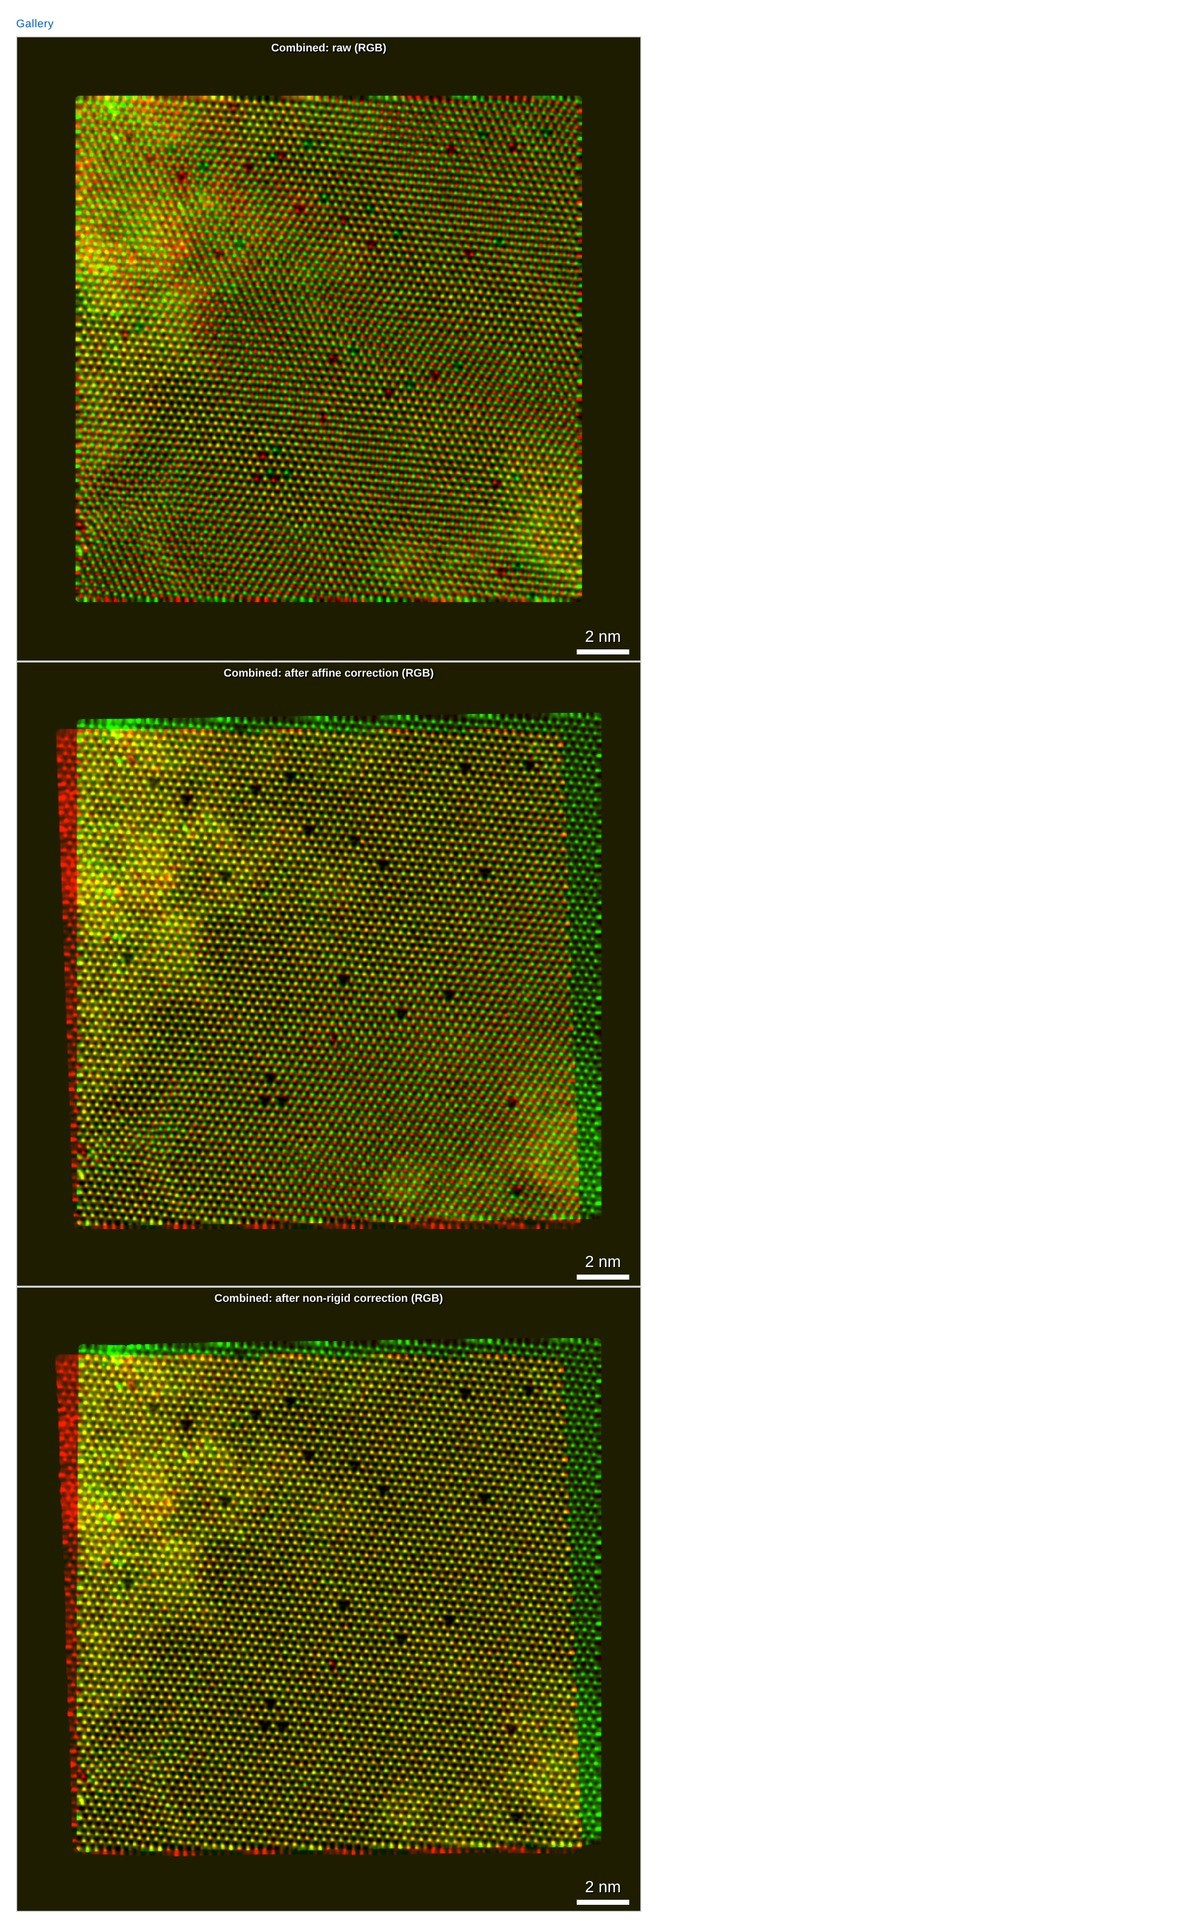

In [8]:
drift.plot_combined(
    stage=("initial", "affine", "nonrigid"),
    interactive=INTERACTIVE,
    width=620,
)


## Validate every region at near-native detail

Every quadrant should settle within about one pixel of its locally preferred
translation. Inspect the RGB panels and `current_ncc` together rather than
treating the global optimization loss as proof of physical registration.

We also tested coarse-to-fine strip correction before this step. It improved
the affine-only lower field, but the final result was indistinguishable after
non-rigid correction, so strip is not part of this WS2
workflow.


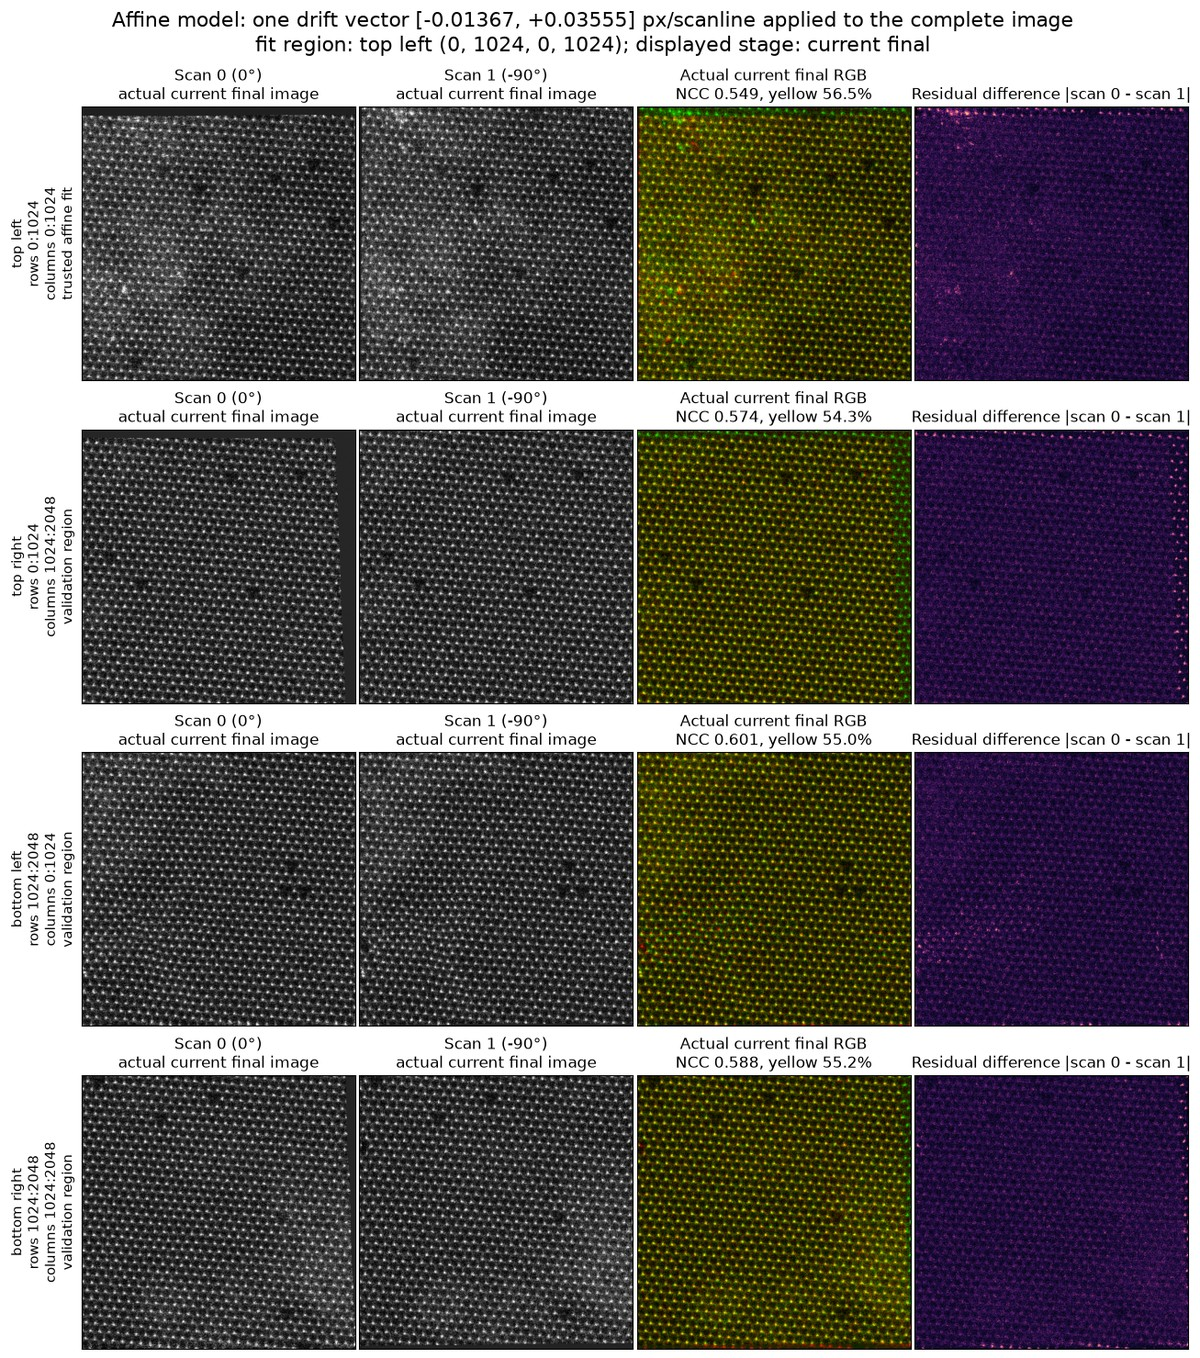

In [9]:
nonrigid_figure, nonrigid_regions = drift.diagnose_affine(
    stage=None,
    smoothing_sigma=0.5,
)


In [10]:
nonrigid_regions


,region,region_role,row_start,row_stop,column_start,column_stop,grid_row,grid_column,current_ncc,current_yellow,mean_absolute_difference
0,top left,trusted affine fit,0,1024,0,1024,0,0,0.549286,0.565447,0.038752
1,top right,validation region,0,1024,1024,2048,0,1,0.573532,0.543106,0.033058
2,bottom left,validation region,1024,2048,0,1024,1,0,0.600756,0.550184,0.034409
3,bottom right,validation region,1024,2048,1024,2048,1,1,0.587521,0.551662,0.034330


## Corrected image gallery


  Display bin 3×: 2560×2560 → 853×853 (16 MB preview; full-res detail streams on zoom)


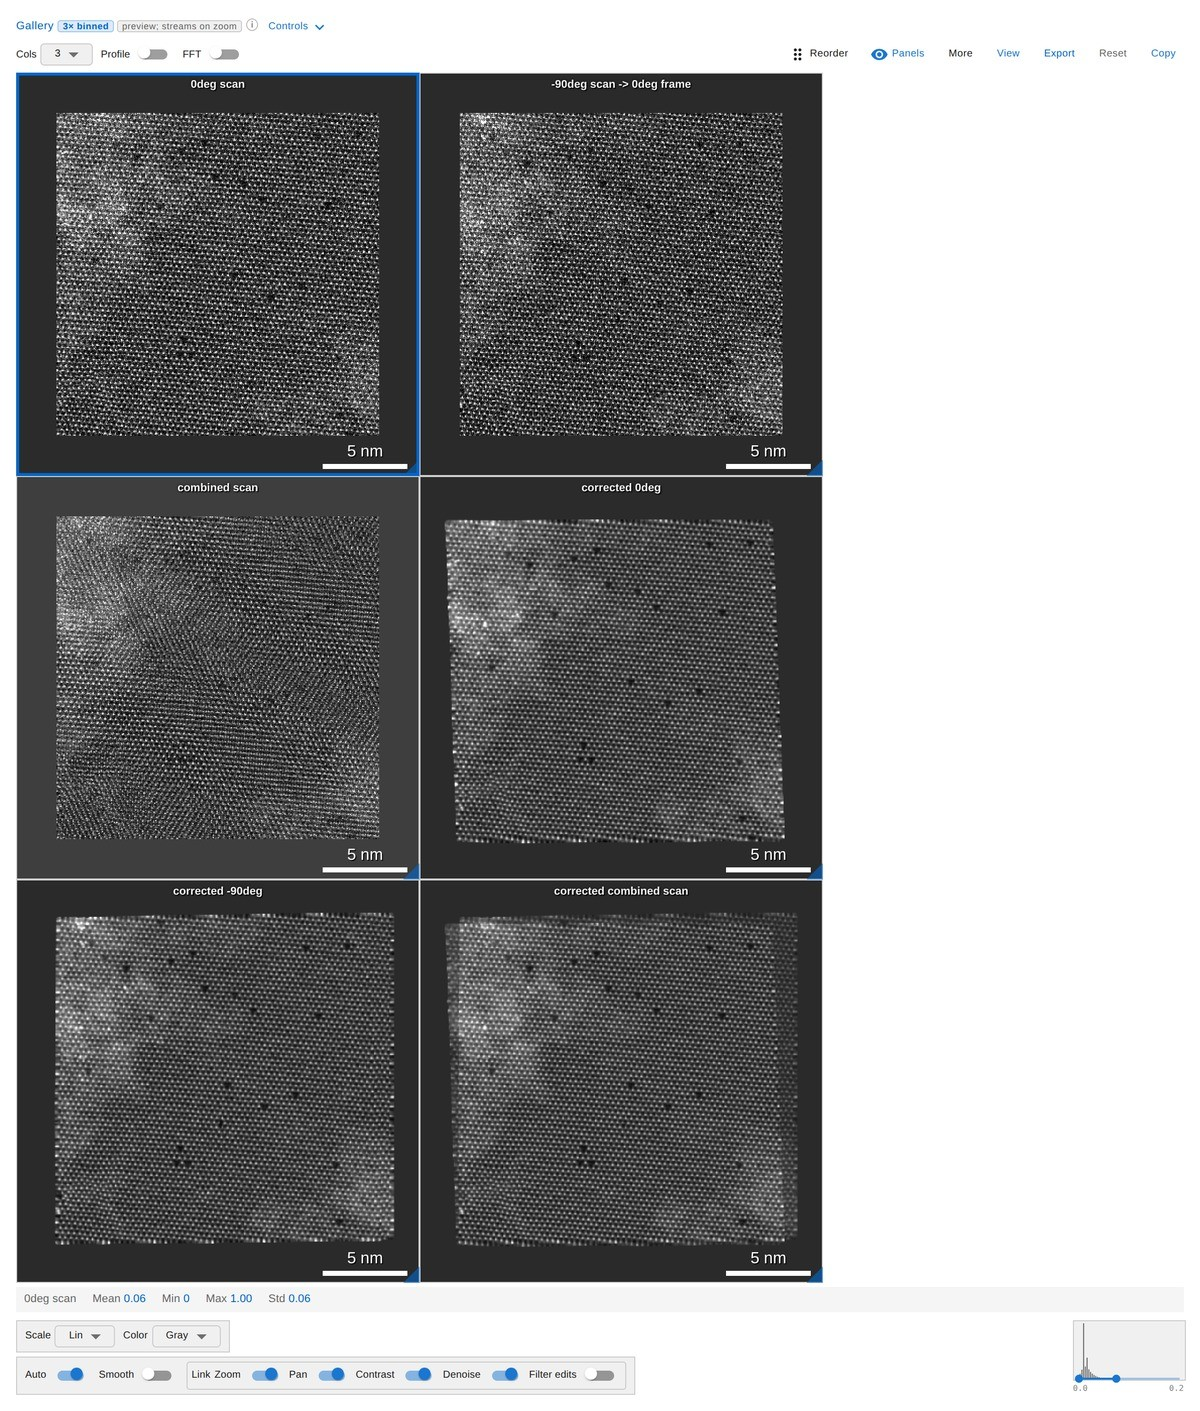

In [11]:
drift.show(
    mode=VIEW_MODE,
    cmap="gray",
    auto_contrast=True,
    link_contrast=True,
    smooth=False,
    show_fft=False,
    save_state=True,
)


## Save the fitted correction

The saved object preserves the regional affine checkpoint and the final
non-rigid knots. It does not copy the raw EMD files.


In [12]:
drift.save(RESULT, mode="o")
print(f"Saved: {RESULT}")


Saved: ../data/robustness/wmill_ws2/drift_0070_0071_diagnostics.zip


## Reproduce

Run this notebook from `tutorials/advanced` with the `live-env`
kernel. Regenerate the notebook source with:

```bash
python tutorials/template/build_2d_affine_diagnostics_ws2_tutorial.py
```

For the publication WS2 pair and its standard non-rigid result, use
`../2d_nonrigid_ws2.ipynb`.
